In [34]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep
import sys
from sklearn.decomposition import PCA
from typing import List, Optional
import timeit
import awkward as ak
import torch
import torch.nn as nn
from torch.nn import Parameter 
from torch.nn.init import xavier_uniform_, xavier_normal_, constant_
import torch
from torch import nn, Tensor
from typing import Optional
import torch.nn.functional as F
from typing import Optional, Tuple
_is_fastpath_enabled: bool = True
from torch.overrides import (
    handle_torch_function,
    has_torch_function,
    has_torch_function_unary,
    has_torch_function_variadic,
)
linear = torch._C._nn.linear
import math
import random
import warnings
import copy
from torch._C import _add_docstr, _infer_size
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
from matplotlib.cm import ScalarMappable

from functools import partial
from weaver.utils.logger import _logger
import os
import uproot
from torch.utils.data import IterableDataset, DataLoader
import numpy as np
from tqdm import tqdm
from torch._torch_docs import reproducibility_notes, sparse_support_notes, tf32_notes

import subprocess
import sys
sys.path.append('../')
import model_utils as mu

In [ ]:
num_models = 21
model_path = '../models/ParT_full.pt'
models = [mu.get_model('jc_full', interaction_strength=1-m_idx/(num_models-1)) for m_idx in range(num_models)]
state_dict = torch.load(model_path, map_location='cpu')
for model in models:
    model.load_state_dict(state_dict)

Defaulting to Jet_Class-trained model configuration
Defaulting to Jet_Class-trained model configuration
Defaulting to Jet_Class-trained model configuration
Defaulting to Jet_Class-trained model configuration
Defaulting to Jet_Class-trained model configuration
Defaulting to Jet_Class-trained model configuration
Defaulting to Jet_Class-trained model configuration
Defaulting to Jet_Class-trained model configuration
Defaulting to Jet_Class-trained model configuration
Defaulting to Jet_Class-trained model configuration


In [32]:
cls_hooks = []
for model in models:
    cls_hooks.append(mu.ParT_Hook(model, type='class token'))
# load small sample of data
n_jets = 9
jc_full_pf_features = np.load('../jc_full_data/jc_full_pf_features.npy')[:n_jets]
jc_kin_pf_features = jc_full_pf_features[:,:7,:]
jc_full_pf_vectors = np.load('../jc_full_data/jc_full_pf_vectors.npy')[:n_jets]
jc_full_pf_mask = np.load('../jc_full_data/jc_full_pf_mask.npy')[:n_jets]
jc_full_pf_points = np.load('../jc_full_data/jc_full_pf_points.npy')[:n_jets]
jc_full_labels = np.load('../jc_full_data/jc_full_labels.npy')[:n_jets]

In [23]:
print(jc_full_labels.shape)

(9, 10)


In [ ]:
cls_hooks = []
for model in models:
    cls_hooks.append(mu.ParT_Hook(model, type='class token'))
# in pod - larger data sample
dataset_size = int(10e5)
n_jets = 10
data_path = '/moe-interpretability/datasets/'
jc_full_pf_features = np.load(os.path.join(data_path, 'jc_full_pf_features.npy'))[::dataset_size//n_jets]
jc_kin_pf_features = jc_full_pf_features[:,:7,:]
jc_full_pf_vectors = np.load(os.path.join(data_path, 'jc_full_pf_vectors.npy'))[::dataset_size//n_jets]
jc_full_pf_mask = np.load(os.path.join(data_path, 'jc_full_pf_mask.npy'))[::dataset_size//n_jets]
jc_full_pf_points = np.load(os.path.join(data_path, 'jc_full_pf_points.npy'))[::dataset_size//n_jets]
jc_full_labels = np.load(os.path.join(data_path, 'jc_full_labels.npy'))[::dataset_size//n_jets]

FileNotFoundError: [Errno 2] No such file or directory: '/moe-interpretability/datasets/jc_full_pf_features.npy'

In [26]:
y_pred = []
for m_idx, model in enumerate(models):
    model.eval()
    with torch.no_grad():
        y_pred.append(model(torch.from_numpy(jc_full_pf_points), torch.from_numpy(jc_full_pf_features), 
                    torch.from_numpy(jc_full_pf_vectors), torch.from_numpy(jc_full_pf_mask)))

cls_tokens = []
for cls_hook in cls_hooks:
    cls_tokens.append(cls_hook.cls_tokens)

/home/tim_legge/Interpreting-Particle-Transformers/ablation_study/../model_utils.py:1800: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):
/home/tim_legge/Interpreting-Particle-Transformers/ablation_study/../model_utils.py:576: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


In [29]:
all_cls_tokens = np.concatenate(cls_tokens, axis=0)
print(all_cls_tokens.shape)  # should be (num_models * n_jets, hidden_dim)
# PCA components on cls tokens
pca = PCA(n_components=2)
cls_tokens_2d = pca.fit_transform(all_cls_tokens)
components = pca.components_
explained_variance = pca.explained_variance_ratio_
print('pca components shape:', components.shape)
print("Explained Variance Ratio:\n", explained_variance)

(90, 128)
pca components shape: (2, 128)
Explained Variance Ratio:
 [0.52997667 0.16078472]


/tmp/ipykernel_117565/1906287270.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(cls_tokens_2d[m_idx*n_jets:(m_idx+1)*n_jets,0][mask], cls_tokens_2d[m_idx*n_jets:(m_idx+1)*n_jets,1][mask],


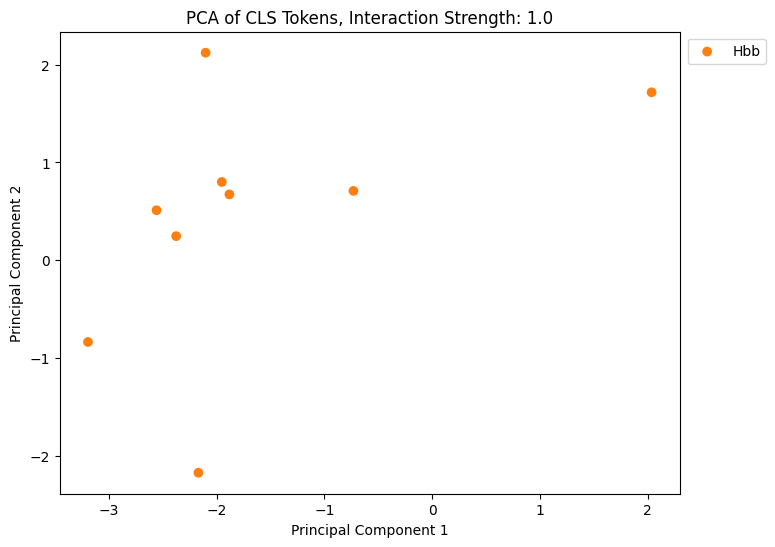

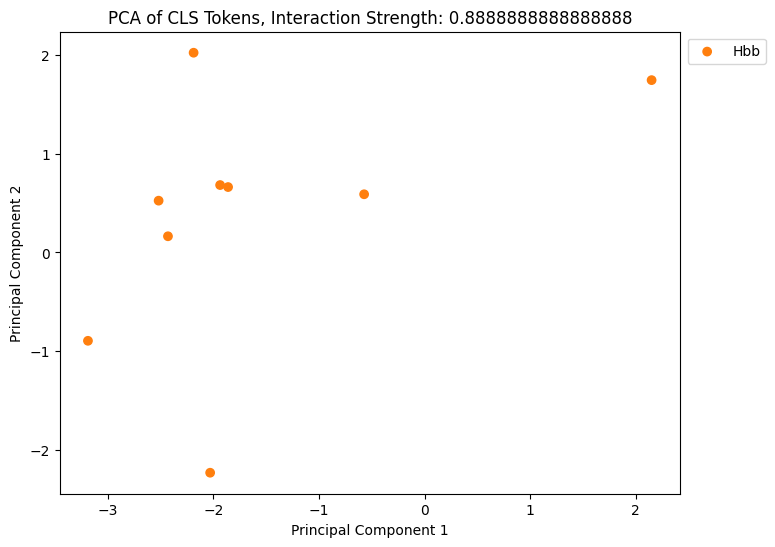

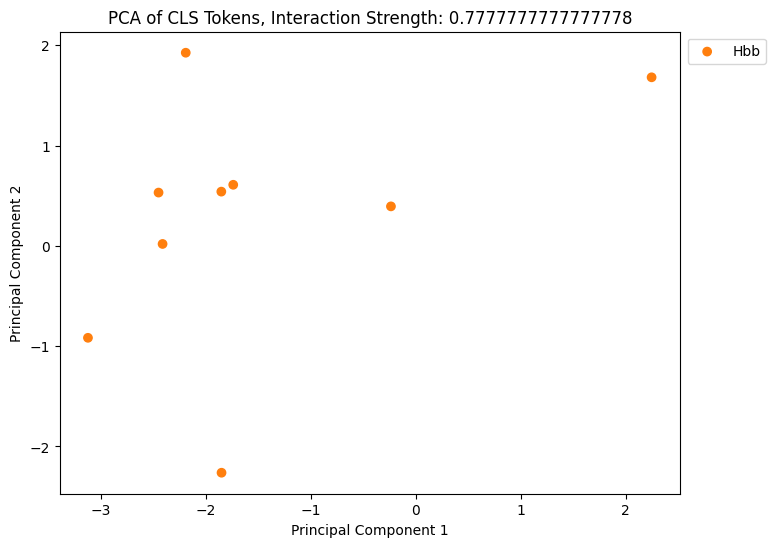

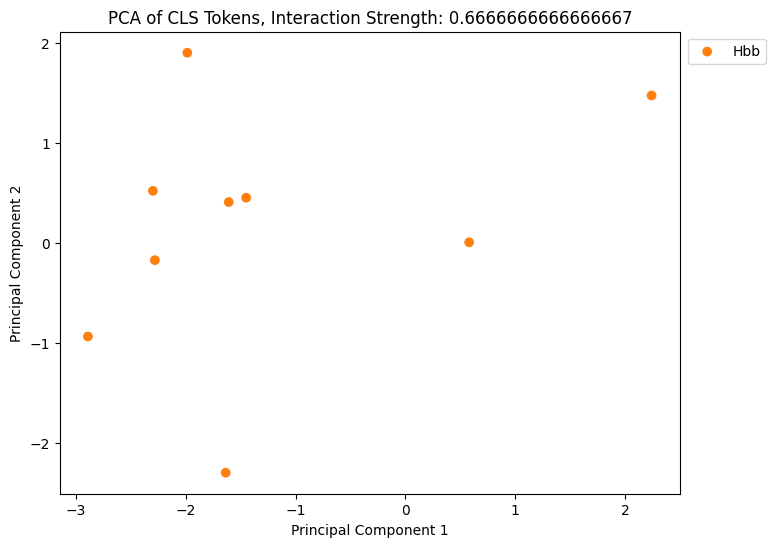

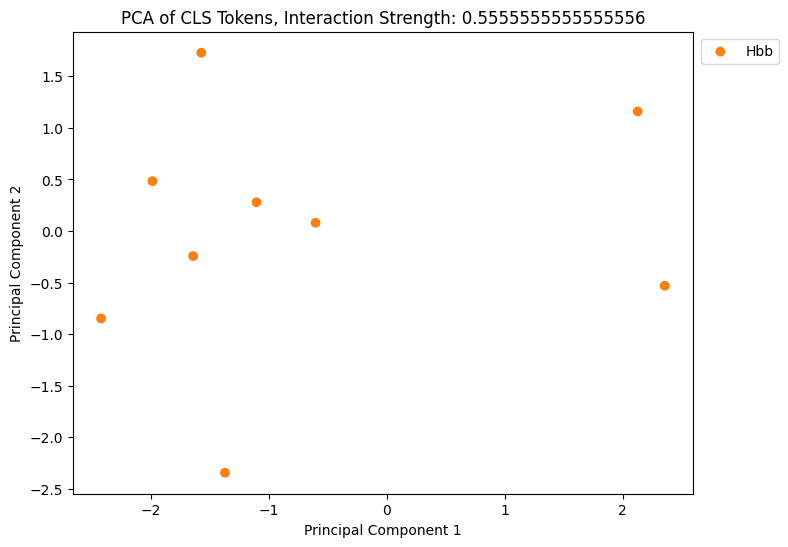

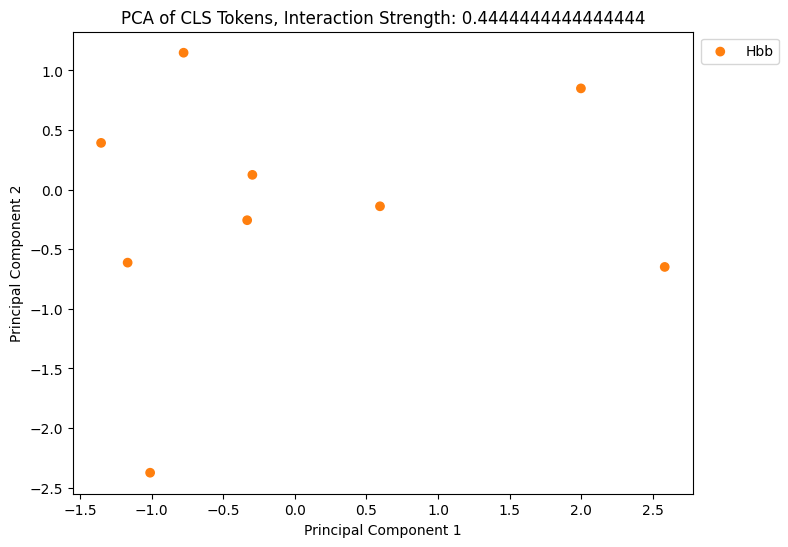

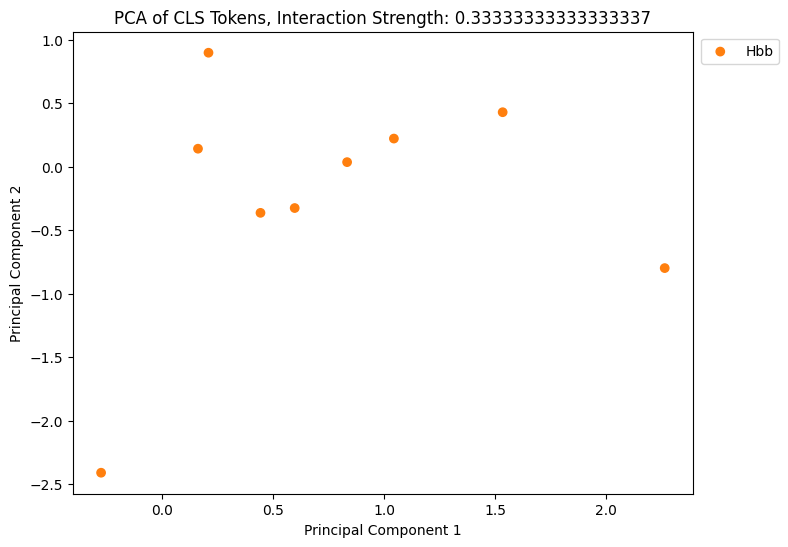

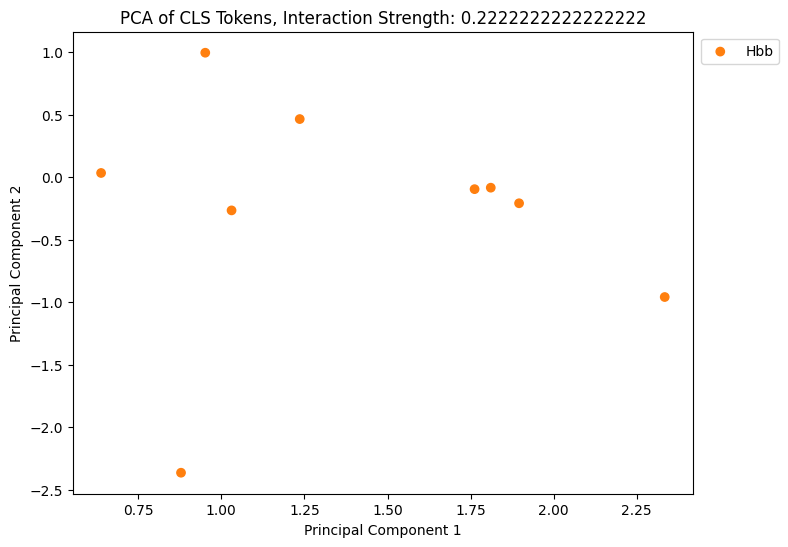

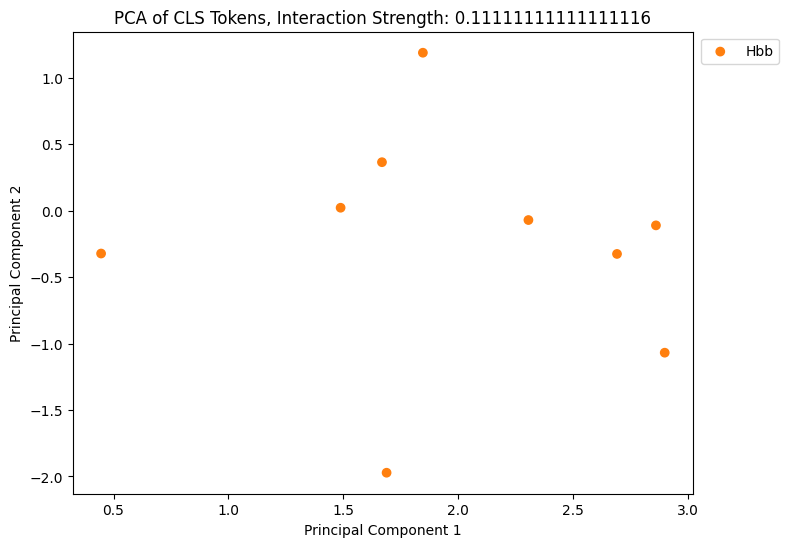

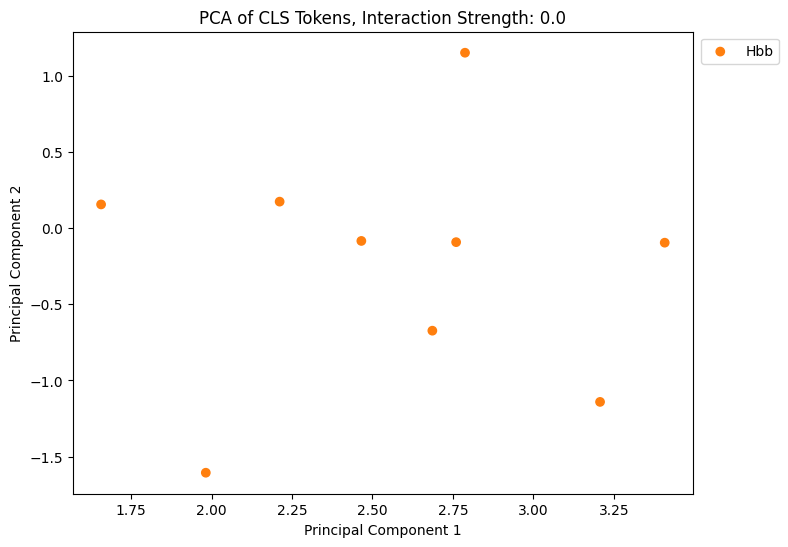

In [ ]:
idx_to_label = ['QCD', 'Hbb', 'Hcc', 'Hgg', 'H4q', 'Hqql', 'Zqq', 'Wqq', 'Tbqq', 'Tbl']
color_idxs = [[f'C{i}'] for i in range(jc_full_labels.shape[1])]
labels = [idx_to_label[np.argmax(jc_full_labels[i])] for i in range(n_jets)]
#if not os.path.exists('./pca_plots'):
#    subprocess.run(['mkdir', './pca_plots'])
for m_idx, model in enumerate(models):
    plt.figure(figsize=(8,6))
    for idx, label in enumerate(idx_to_label):
        mask = np.where(jc_full_labels[:,idx] == 1)[0]
        if len(mask) == 0:
            continue
        else:
            plt.scatter(cls_tokens_2d[m_idx*n_jets:(m_idx+1)*n_jets,0][mask], cls_tokens_2d[m_idx*n_jets:(m_idx+1)*n_jets,1][mask], 
                c=color_idxs[idx]*len(mask), label=label,
                cmap='viridis')
    #plt.colorbar(label='Jet Class')
    plt.title(f'Projection of CLS Tokens, Interaction Strength: {model.mod.interaction_strength}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    #plt.savefig(f'./pca_plots/pca_cls_tokens_model_{m_idx}.png')
    plt.show()